In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('health_dataset.csv')

# Select features for clustering
features = df[['Age', 'Systolic', 'Diastolic', 'BMI']]
df.head(10)

,Patient_ID,Age,BMI,Systolic,Diastolic,Gender
0,1,58,30.8,144,97,Male
1,2,71,29.7,164,130,Female
2,3,48,39.2,145,108,Male
3,4,34,36.7,106,76,Female
4,5,62,34.6,127,80,Male
5,6,27,30.1,113,71,Female
6,7,40,31.1,158,97,Male
7,8,58,39.3,159,123,Female
8,9,77,31.6,175,126,Male
9,10,38,24.4,100,74,Female


In [10]:
# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [11]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features_scaled)

In [12]:
# Group the data by Cluster
cluster_0 = df[df['Cluster'] == 0]
cluster_1 = df[df['Cluster'] == 1]
cluster_2 = df[df['Cluster'] == 2]

# Print the data for each cluster
print("Cluster 0: Moderate Health Risk")
print(cluster_0[['Patient_ID', 'Age', 'BMI', 'Systolic','Diastolic']])
print("\nCluster 1: Low To Moderate Health Risk")
print(cluster_1[['Patient_ID', 'Age', 'BMI', 'Systolic','Diastolic']])
print("\nCluster 2: High Health Risk")
print(cluster_2[['Patient_ID', 'Age', 'BMI', 'Systolic','Diastolic']])

# Optional: Calculate summary statistics for each cluster
print("\nSummary Statistics for Cluster 0: Moderate Health Risk")
print(cluster_0[['Age', 'BMI', 'Systolic','Diastolic']].describe())
print("\nSummary Statistics for Cluster 1: Low To Moderate Health Risk")
print(cluster_1[['Age', 'BMI', 'Systolic','Diastolic']].describe())
print("\nSummary Statistics for Cluster 2: High Health Risk")
print(cluster_2[['Age', 'BMI', 'Systolic','Diastolic']].describe())


Cluster 0: Moderate Health Risk
    Patient_ID  Age   BMI  Systolic  Diastolic
4            5   62  34.6       127         80
16          17   59  18.8       109         72
23          24   63  38.2       109         73
27          28   79  26.5       129         91
31          32   77  24.4       100         63
35          36   68  36.8       112         85
37          38   78  23.6       131         81
38          39   61  24.0        96         71
43          44   66  22.8        90         70
44          45   70  37.8       137         89
45          46   63  28.7       101         74
47          48   71  33.5       126         89
48          49   76  21.5       121         86
50          51   56  30.1       108         86
51          52   70  22.9       137        103
55          56   58  37.4       113         89
61          62   69  27.5       125         82
62          63   77  37.5       127         97
65          66   72  26.2       114         81
70          71   79  26.1   

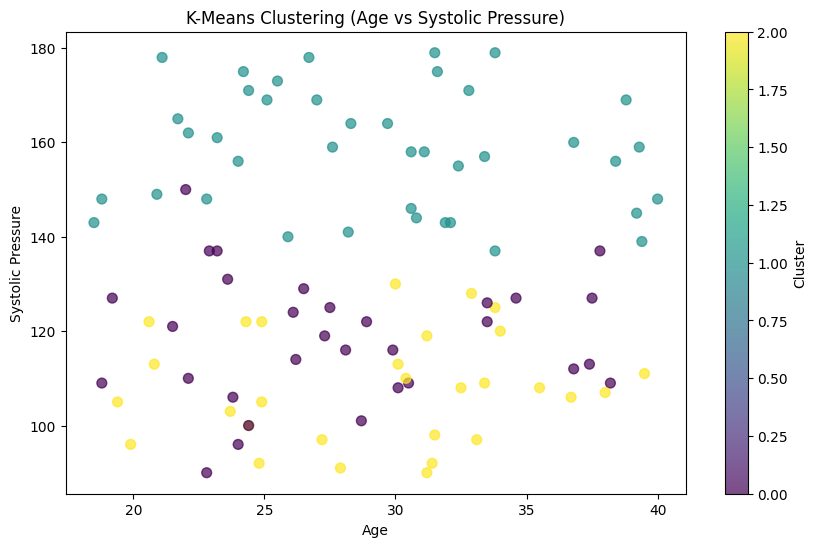

In [6]:
# Scatter plot for Age vs Systolic Pressure
plt.figure(figsize=(10, 6))
plt.scatter(df['BMI'], df['Systolic'], c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Systolic Pressure')
plt.title('K-Means Clustering (Age vs Systolic Pressure)')
plt.colorbar(label='Cluster')
plt.show()

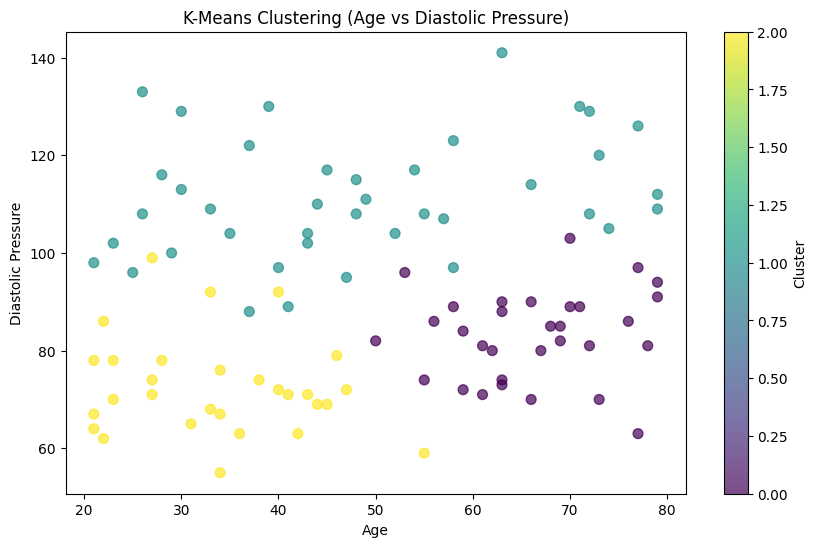

In [7]:
# Scatter plot for Age vs Diastolic Pressure
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Diastolic'], c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Diastolic Pressure')
plt.title('K-Means Clustering (Age vs Diastolic Pressure)')
plt.colorbar(label='Cluster')
plt.show()

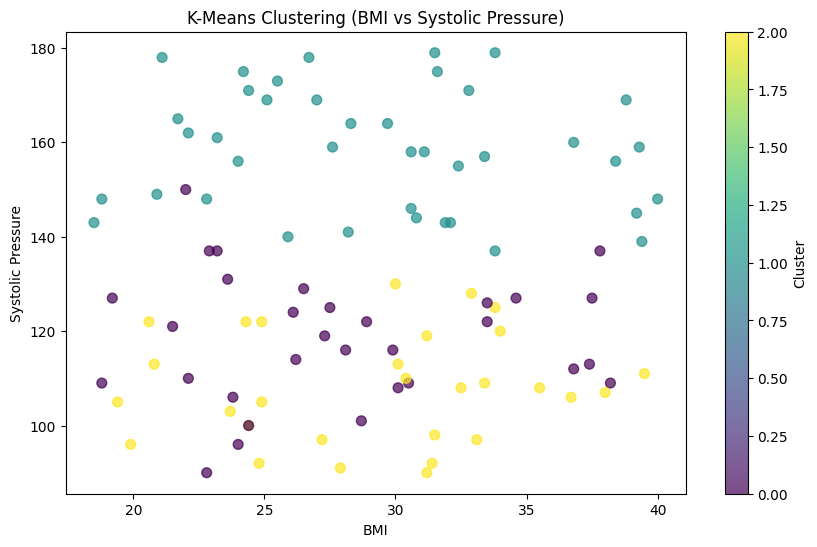

In [8]:
# Scatter plot for BMI vs Systolic Pressure
plt.figure(figsize=(10, 6))
plt.scatter(df['BMI'], df['Systolic'], c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.xlabel('BMI')
plt.ylabel('Systolic Pressure')
plt.title('K-Means Clustering (BMI vs Systolic Pressure)')
plt.colorbar(label='Cluster')
plt.show()